<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/HW_4/Week04_Interpolation_Kriging_Kwanda_1077167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import libraries**

In [26]:
!pip install -q geostatspy statsmodels geostatsmodels numba

In [27]:
import os                                                     # for file and directory operations
import numpy as np                                            # for numerical operations and ndarrays
import pandas as pd                                           # for handling data in DataFrame format
import matplotlib.pyplot as plt                               # for plotting and visualization
from statsmodels.stats.weightstats import DescrStatsW         # for weighted statistics calculations
from scipy.optimize import curve_fit                          # for curve fitting
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization, and wrapper functions
import geostatspy.geostats as geostats                        # GSLIB methods converted to Python
import geostatspy                                             # for accessing the package version and general utilities


from tqdm import tqdm                                         # progress bar for loops
from functools import partialmethod                           # used to modify tqdm to suppress the status bar
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)    # suppress the status bar for tqdm

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control over axes ticks in plots
plt.rc('axes', axisbelow=True)                                # ensure grid lines are plotted below plot elements

import scipy.spatial as sp                                    # for spatial data structures and algorithms (KDTree)
import geopandas as gpd                                       # for handling geospatial data (GeoDataFrame)
from matplotlib import gridspec                               # custom subplots

# Define ignore_warnings before using it
ignore_warnings = True                                        # flag to ignore warnings

# Check and apply the warning filter
if ignore_warnings == True:
    import warnings
    warnings.filterwarnings('ignore')

from IPython.utils import io                                  # mute output from simulation

cmap = "Spectral_r"                                           # color map


# **Functions**

In [28]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks

def add_grid():
    ax = plt.gca()
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# **1. Data & Week 3 Foundations**

### 1.1 Load Data

In [29]:
# Load data from Github
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/HW_4/CuMineBH.csv"
df = pd.read_csv(url)
df_cu = df.copy()
df_cu.head()

,EAST,NORTH,Cu
0,56.122424,105.841818,0.750
1,74.176970,81.483939,0.664
2,140.032424,191.491515,0.202
3,158.912121,133.599697,0.408
4,50.455455,211.942121,0.602


##### Summary statistics

In [30]:
df_cu.describe().T

,count,mean,std,min,25%,50%,75%,max
EAST,1575.0,255.912312,158.598035,0.000,119.457424,237.761515,401.520303,561.063636
NORTH,1575.0,155.871652,63.364120,0.000,113.178939,163.326061,207.209848,268.143939
Cu,1575.0,0.405832,0.230091,0.026,0.244000,0.356000,0.522000,1.968000


##### Scatter Map

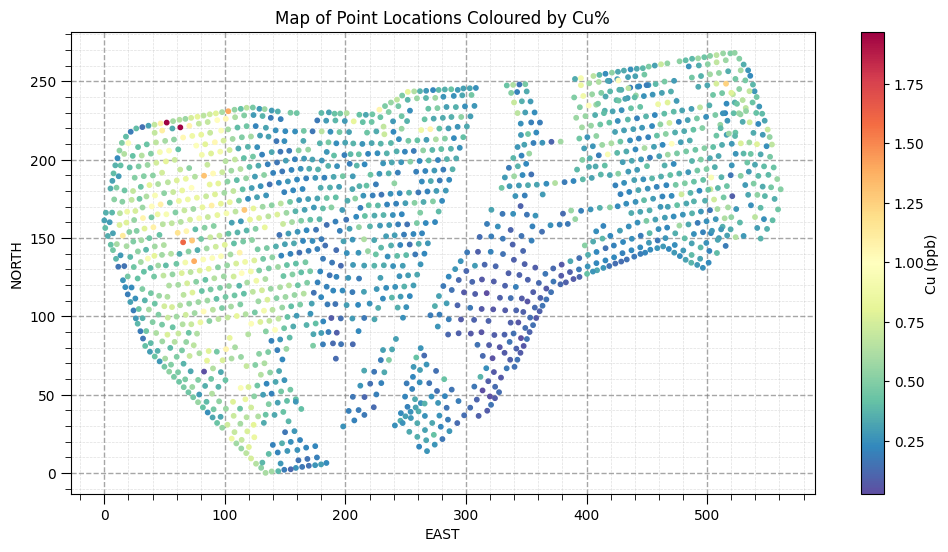

In [31]:
# Create the figure and axis
fig, ax = plt.subplots(figsize = (12, 6))
# Create the scatter plot
sc = ax.scatter(df_cu['EAST'],df_cu['NORTH'], s = 10,c = df_cu['Cu'], cmap = cmap)
# Create the grid
ax.grid(True, color = 'grey', linestyle = '--', linewidth = 0.5)

# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')
ax.set_title('Map of Point Locations Coloured by Cu%')

# Add a colorbar
cbar = plt.colorbar(sc, ax = ax)
cbar.set_label('Cu (ppb)', rotation = 90, labelpad = 0)
cbar.ax.tick_params(labelsize=10)
add_grid()

# Display the plot
plt.show()

### 1.2 Declustering recap

In [35]:
# Adding declustered weights
df_cu["declust_weight"], cell_size, declust_means = geostats.declus(
    df_cu, 'EAST', 'NORTH', 'Cu',
    iminmax = 1, noff = 100, ncell = 200, cmin = 1, cmax = 500)

# Calculate naive and declustered means
weighted_data = DescrStatsW(df_cu["Cu"].values, weights = df_cu["declust_weight"].values, ddof = 0)
dmean = round(weighted_data.mean, 3)
naive_mean = round(np.mean(df_cu["Cu"].values), 3)
# storing declustered mean
mu_declust = dmean

print("Naive mean =", naive_mean)
print("Declustered mean =", dmean)

There are 1575 data with:
   mean of      0.405832380952381 
   min and max  0.026 and 1.968
   standard dev 0.23001832880532494 
Naive mean = 0.406
Declustered mean = 0.38


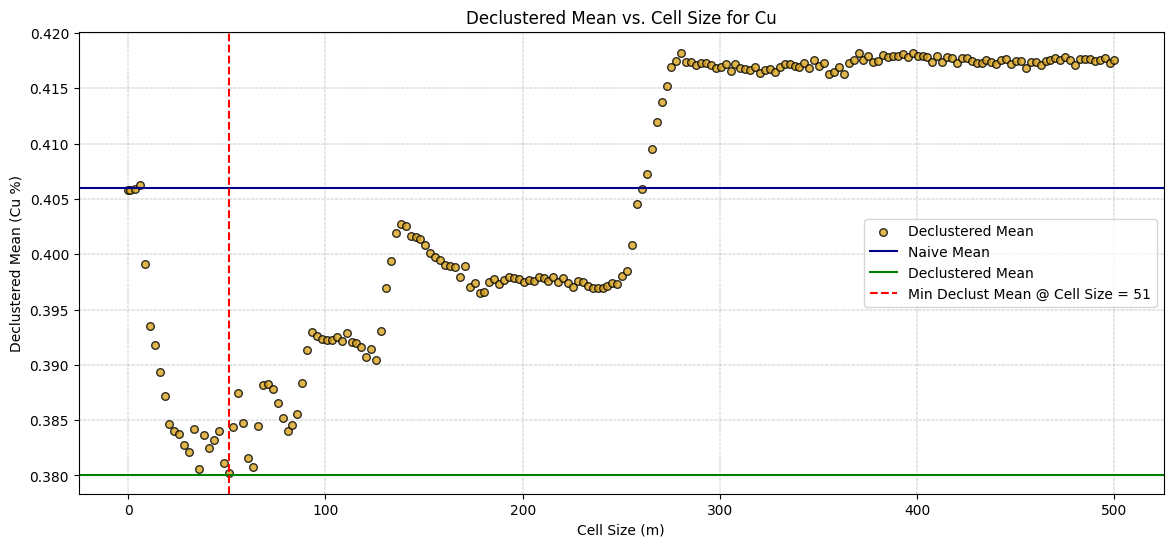

In [39]:
# Identify best declustered cell size (min of declust_means)
min_dmean_idx = np.argmin(declust_means)
best_cell_size = cell_size[min_dmean_idx]
min_declust_val = declust_means[min_dmean_idx]

# Create the plot
plt.figure(figsize=(14, 6))
plt.scatter(cell_size, declust_means, s = 30, alpha = 0.8,
            edgecolors = "black", facecolors = 'goldenrod', label = 'Declustered Mean')

# Horizontal lines
plt.axhline(y = naive_mean, color = 'darkblue', linestyle = '-', label = 'Naive Mean')
plt.axhline(y = dmean, color = 'green', linestyle = '-', label = 'Declustered Mean')

# Vertical line at minimum declustered mean
plt.axvline(x = best_cell_size, color = 'red', linestyle = '--',
            label = f'Min Declust Mean @ Cell Size = {best_cell_size:.0f}')

# Labels, title, grid, legend
plt.xlabel('Cell Size (m)')
plt.ylabel('Declustered Mean (Cu %)')
plt.title('Declustered Mean vs. Cell Size for Cu')
plt.grid(color = 'grey', linestyle = '-.', linewidth = 0.3, which = 'both')
plt.legend()

# Show the plot
plt.show()

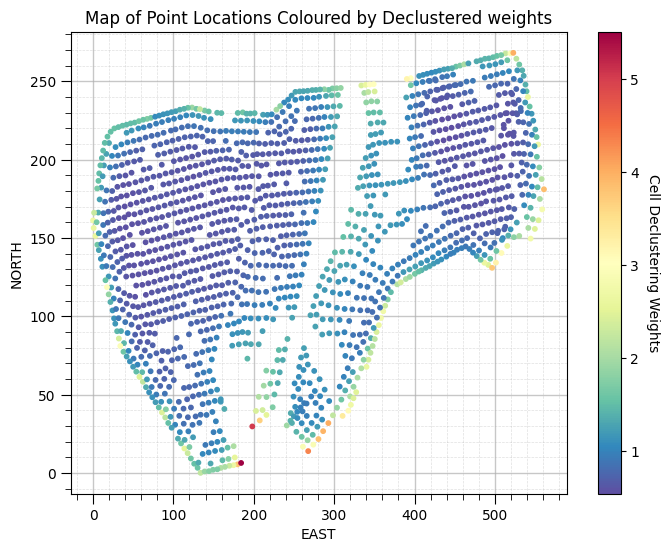

In [41]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the scatter plot
sc = ax.scatter(df_cu['EAST'], df_cu['NORTH'], s = 10, c = df_cu['declust_weight'], cmap = 'Spectral_r')

# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')
ax.set_title('Map of Point Locations Coloured by Declustered weights')

# Add a colorbar
cbar = plt.colorbar(sc, ax = ax)
cbar.set_label('Cell Declustering Weights', rotation = 270, labelpad = 15)
cbar.ax.tick_params(labelsize=10)
add_grid()

# Display the plot
plt.show()


In [42]:
# Calculate naive statistics
naive_stats = df_cu['Cu'].describe(percentiles=[0.25, 0.75])

# Calculate declustered statistics using weighted statistics
declust_mean = weighted_data.mean
declust_min = np.min(df_cu['Cu'].values)
declust_q1 = weighted_data.quantile(0.25).item()  # Convert to scalar using item()
declust_q3 = weighted_data.quantile(0.75).item()  # Convert to scalar using item()
declust_max = np.max(df_cu['Cu'].values)

# Construct the table data
table_data = {
    "Copper Data": ["Naive", "Declustered", "Difference"],
    "Min [ppb]": [round(naive_stats['min'], 2), round(declust_min, 2), round(declust_min - naive_stats['min'], 2)],
    "Q1 [ppb]": [round(naive_stats['25%'], 2), round(declust_q1, 2), round(declust_q1 - naive_stats['25%'], 2)],
    "Mean [ppb]": [round(naive_stats['mean'], 2), round(declust_mean, 2), round(declust_mean - naive_stats['mean'], 2)],
    "Q3 [ppb]": [round(naive_stats['75%'], 2), round(declust_q3, 2), round(declust_q3 - naive_stats['75%'], 2)],
    "Max [ppb]": [round(naive_stats['max'], 2), round(declust_max, 2), round(declust_max - naive_stats['max'], 2)]
}

# Create a DataFrame for the table
summary_table_df = pd.DataFrame(table_data)
summary_table_df


,Copper Data,Min [ppb],Q1 [ppb],Mean [ppb],Q3 [ppb],Max [ppb]
0,Naive,0.03,0.24,0.41,0.52,1.97
1,Declustered,0.03,0.23,0.38,0.49,1.97
2,Difference,0.00,-0.02,-0.03,-0.03,0.00


### 1.3 Normal score transform (NST) recap

In [43]:
df_cu["nscore"], tv, tns = geostats.nscore(df_cu, "Cu", "declust_weight")
df_cu.head()

,EAST,NORTH,Cu,declust_weight,nscore
0,56.122424,105.841818,0.750,0.625712,1.505209
1,74.176970,81.483939,0.664,0.695047,1.243489
2,140.032424,191.491515,0.202,0.621814,-0.847655
3,158.912121,133.599697,0.408,0.648315,0.352247
4,50.455455,211.942121,0.602,0.892424,1.066072


In [44]:
# Extracting features
feature = "Cu"
feature_units = "ppb"
vmin = df_cu["Cu"].min()
vmax = df_cu["Cu"].max()
xmin = df_cu["EAST"].min()
xmax = df_cu["EAST"].max()
ymin = df_cu["NORTH"].min()
ymax = df_cu["NORTH"].max()

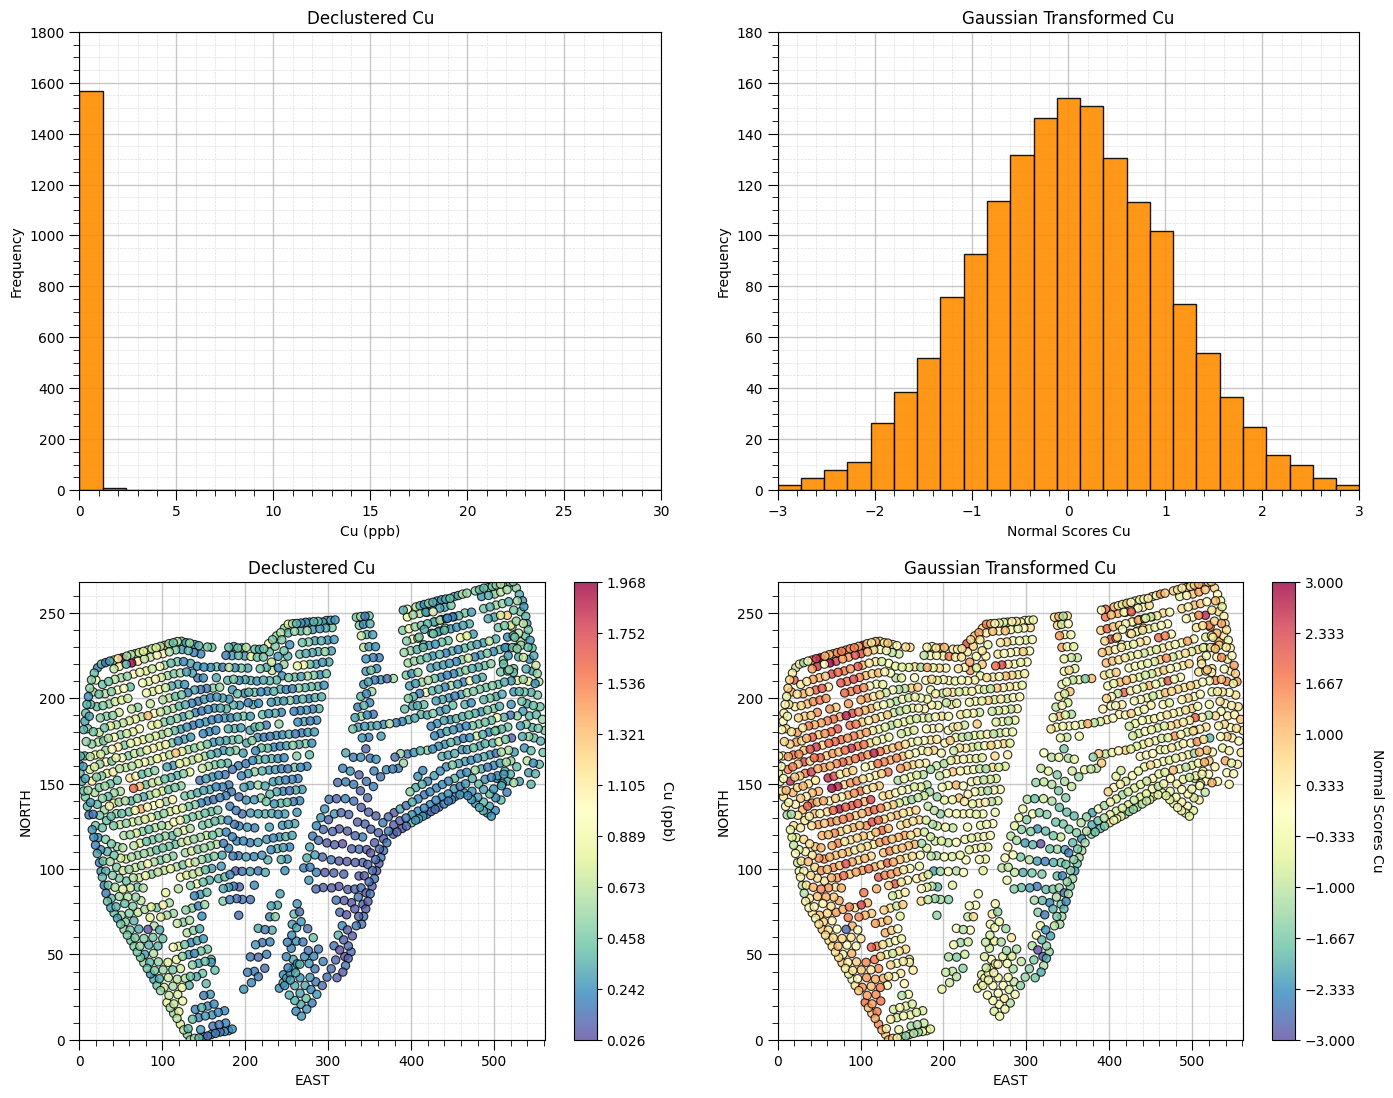

In [65]:
plt.subplot(221)
GSLIB.hist_st(df_cu['Cu'],0,30,log = False,cumul = False,bins = 25,weights = df_cu['declust_weight'],xlabel = "Cu (ppb)",title = "Declustered Cu")
plt.ylim(0.0,1800)
add_grid()
plt.subplot(222)
GSLIB.hist_st(df_cu['nscore'],-3.0,3.0,log = False,cumul = False,bins = 25,weights = df_cu['declust_weight'],xlabel = "Normal Scores Cu",title = "Gaussian Transformed Cu")
plt.ylim(0.0,180)
add_grid()
plt.subplot(223)
GSLIB.locmap_st(df_cu,'EAST','NORTH','Cu',xmin,xmax,ymin,ymax,vmin,vmax,'Declustered Cu','EAST','NORTH','Cu (ppb)',cmap)
add_grid()
plt.subplot(224)
GSLIB.locmap_st(df_cu,'EAST','NORTH','nscore',xmin,xmax,ymin,ymax,-3.0,3.0,'Gaussian Transformed Cu','EAST','NORTH','Normal Scores Cu',cmap)
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 2.1, wspace = 0.2, hspace = 0.2)
plt.show()

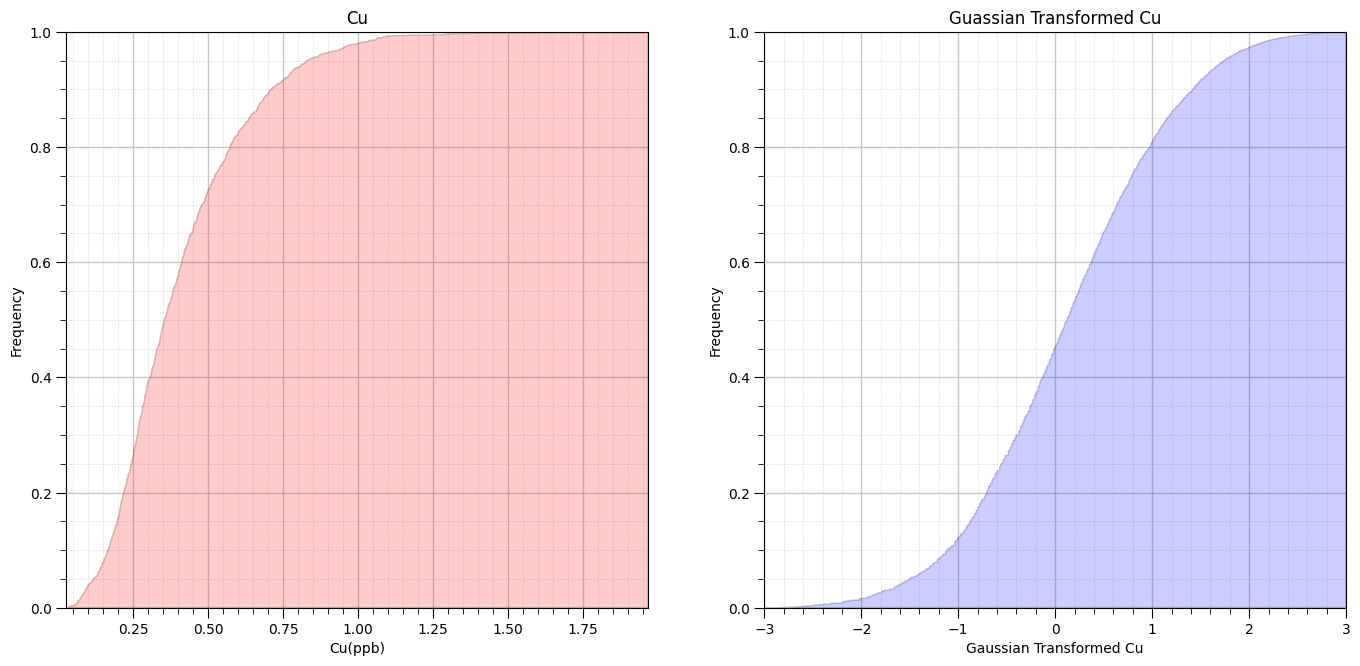

In [72]:
plt.subplot(121)

plt.hist(df_cu[feature], facecolor = 'red',bins=np.linspace(vmin,vmax,1000),histtype = "stepfilled",alpha = 0.2,density = True,cumulative = True,edgecolor = 'black')
plt.xlim([vmin,vmax]); plt.ylim([0,1.0])
plt.xlabel(feature + '(' + feature_units + ')'); plt.ylabel('Frequency'); plt.title('Cu')
add_grid()

plt.subplot(122)
plt.hist(df_cu['nscore'], facecolor = 'blue',bins = np.linspace(-3.0,3.0,1000),histtype = "stepfilled",alpha = 0.2,density = True,cumulative = True,edgecolor = 'black')
plt.xlim([-3.0,3.0]); plt.ylim([0,1.0])
plt.xlabel('Gaussian Transformed ' + feature); plt.ylabel('Frequency'); plt.title('Guassian Transformed ' + feature)
add_grid()

plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.2, wspace = 0.2, hspace = 0.3)
output_file = 'Cu_CuNScore_CDF.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

### 1.4 Variogram recap & model selection

In [91]:
# ───────────────────────────────────────────────
# Variogram Parameter Setup (GSLIB/GeoStatSpy style)
# ───────────────────────────────────────────────

tmin = -99999         # Minimum value threshold (no trimming applied here)
tmax = 99999          # Maximum value threshold (no trimming applied here)

lag_dist = 8         # Lag spacing (distance between successive lags in variogram)
lag_tol = lag_dist*0.5  # Lag tolerance (half lag distance allows ±3.5 units tolerance)

nlag = 25            # Number of lag bins to compute the variogram over

bandh = 9999.9        # Bandwidth (across-strike tolerance); very large value disables band restriction (omnidirectional)

atol = 15           # Azimuth tolerance (in degrees); allows matching directions within ±22.5° of specified azimuth

isill = 1             # Sill standardisation (1 = experimental variogram is normalised to sill = 1)

azi_mat = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165]
                     # Azimuth directions (in degrees) to compute directional variograms
                     # Note: there’s a duplication of 135 – check for typo or intentional redundancy

xlimax = lag_dist * nlag  # Maximum distance on x-axis for variogram plot (controls display range)

min_samples = 3      # Minimum number of pairs required per lag to compute a valid semivariance


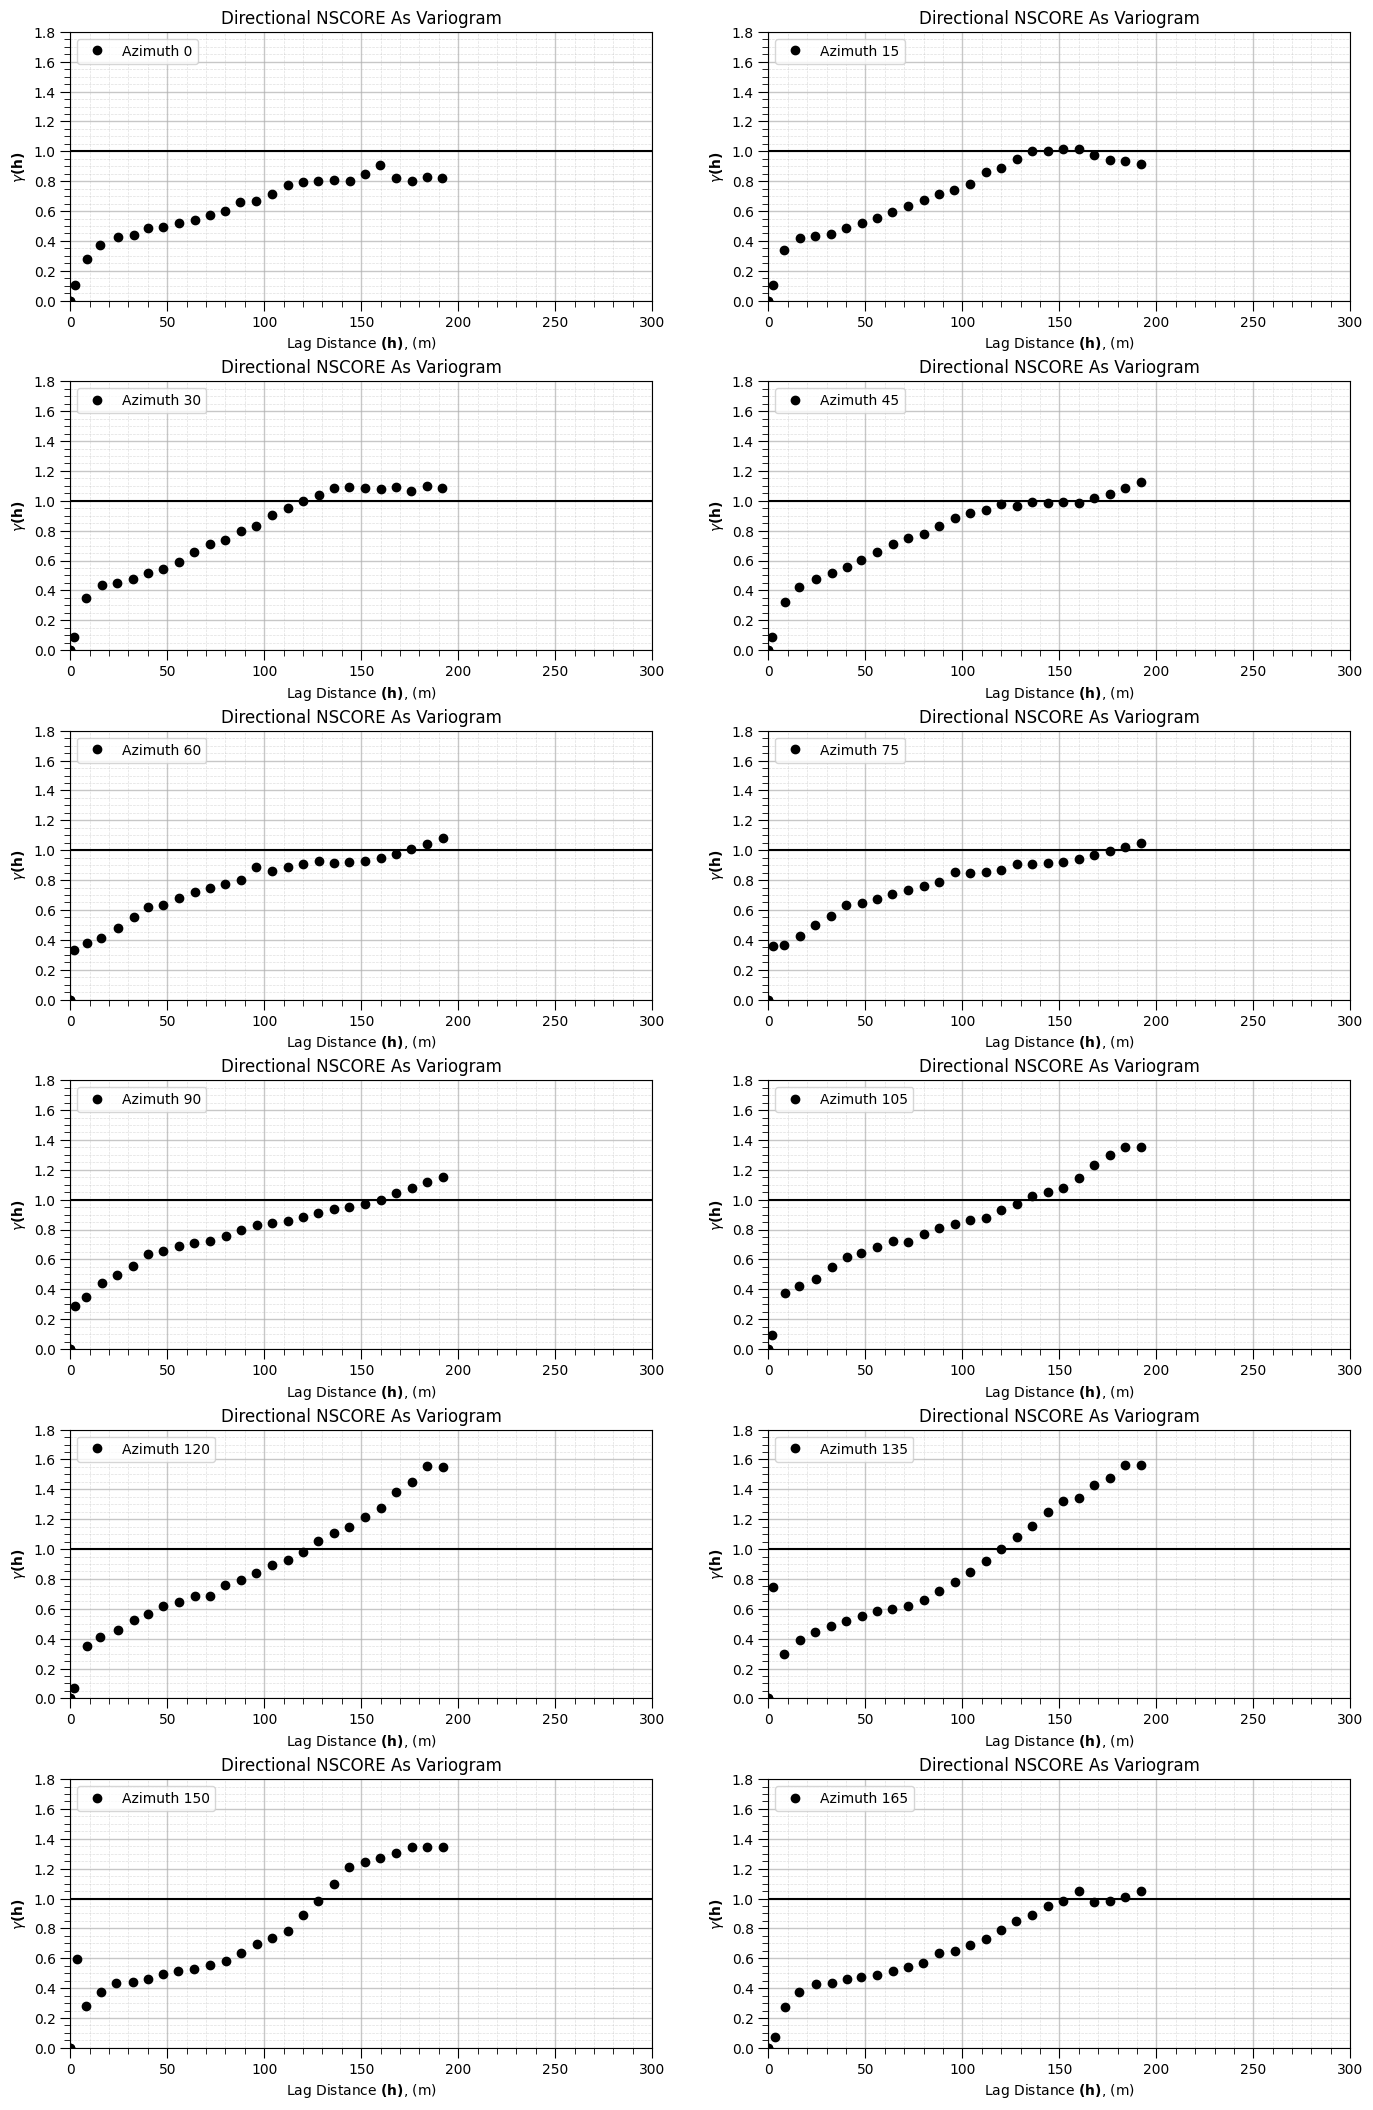

In [92]:
# Arrays to store the results
lag = np.zeros((len(azi_mat),nlag+2)); gamma = np.zeros((len(azi_mat),nlag+2)); npp = np.zeros((len(azi_mat),nlag+2));

for iazi in range(0,len(azi_mat)):                      # Loop over all directions
    lag[iazi,:], gamma[iazi,:], npp[iazi,:] = geostats.gamv(df_cu,"EAST","NORTH","nscore",tmin,tmax,lag_dist,lag_tol,nlag,azi_mat[iazi],atol,bandh,isill)
    plt.subplot(6,2,iazi+1)  # Changed subplot layout to 4 rows and 3 columns
    plt.plot(lag[iazi,:],gamma[iazi,:],'o',color = 'black',label = 'Azimuth ' +str(azi_mat[iazi]))
    plt.plot([0,2000],[1.0,1.0],color = 'black')
    plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
    plt.ylabel(r'$\gamma \bf(h)$')
    plt.title('Directional NSCORE As Variogram')
    plt.xlim([0,300])
    plt.ylim([0,1.8])
    plt.legend(loc='upper left')
    add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=4.2, wspace=0.2, hspace=0.3)
plt.show()

- We can observe that Azimuth 000 is the major direction and Azimuth 090 is the minor direction. at 000 the sill is not reached, hence it is the maximum distance, and it follows that the orthogonal direction to that is 090.

- This corresponds to imajor = 0 and iminor = 6

Major direction is 0 azimuth.
Minor direction is 90 azimuth.


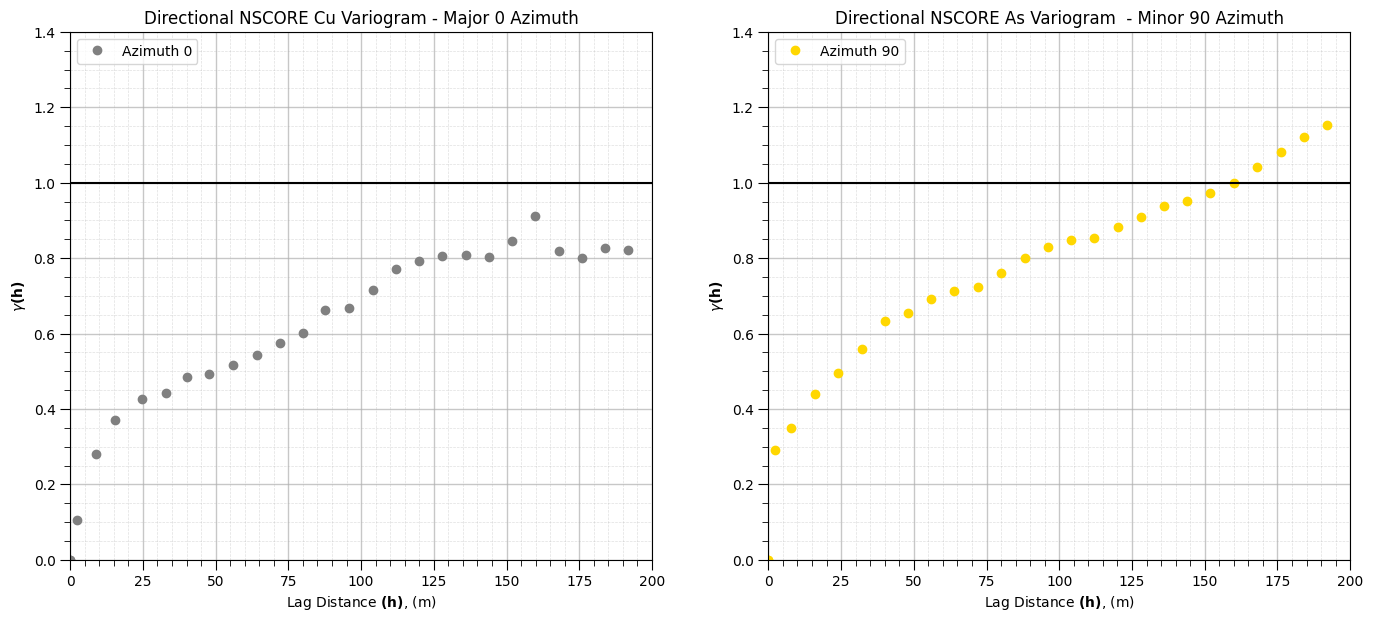

In [93]:
# Select the plot above for the major and minor
imajor = 0
iminor = 6

print('Major direction is ' + str(azi_mat[imajor]) + ' azimuth.')
print('Minor direction is ' + str(azi_mat[iminor]) + ' azimuth.')

if not abs(azi_mat[imajor] - azi_mat[iminor]) == 90.0:
    print('Major and minor directions must be orthogonal to each other.')
    sys.exit()

plt.subplot(1,2,1)
plt.plot(lag[imajor,:],gamma[imajor,:],'o',color = 'grey',label = 'Azimuth ' + str(azi_mat[imajor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc='upper left')
add_grid()
plt.subplot(1,2,2)
plt.plot(lag[iminor,:],gamma[iminor,:],'o',color = 'gold',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc='upper left')
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.3); plt.show()

#### Spherical fit

 x,y,z offsets = 0.0,10.0
 x,y,z offsets = 10.0,1.794896514920806e-08


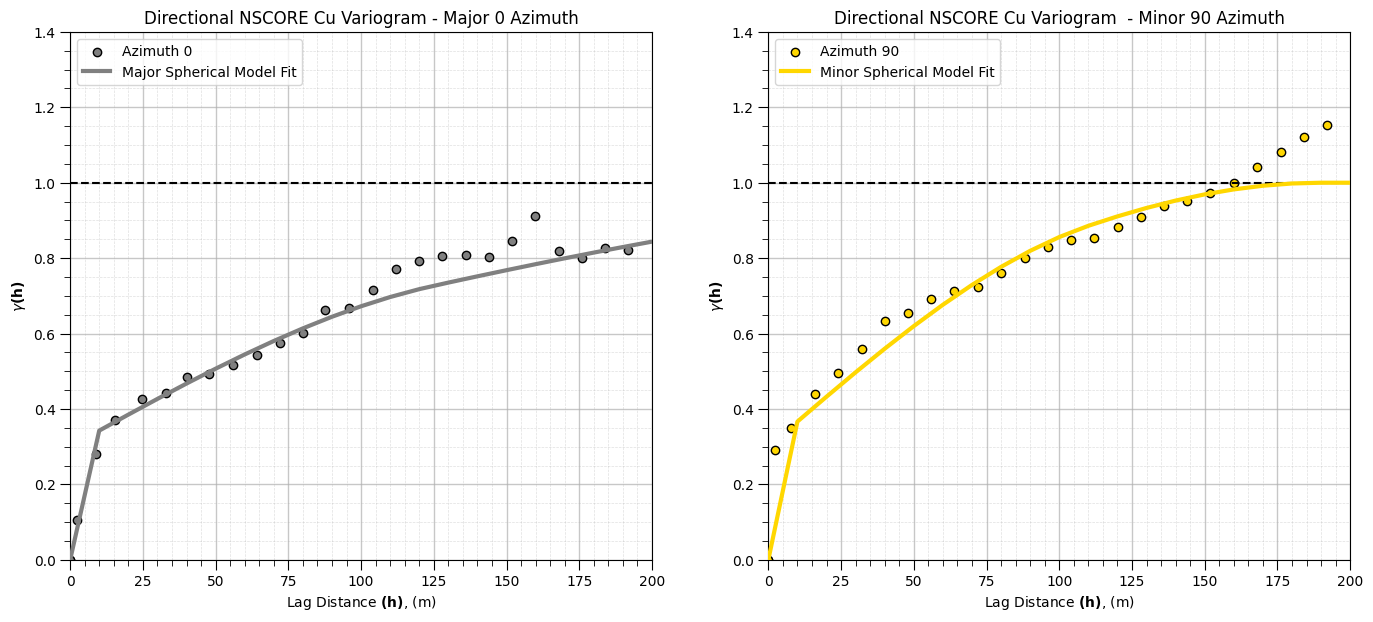

In [118]:
nug = 0.30; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 1; cc1 = 0.20; azi1 = azi_mat[imajor]; hmaj1 = 125; hmin1 = 110
it2 = 1; cc2 = (1-(nug + cc1)); azi2 = azi_mat[imajor]; hmaj2 = 400; hmin2 = 190

vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2) # make model object
nlag = 25; xlag = 10;                                          # project the model in the 045 azimuth
index_maj,h_maj,gam_maj,cov_maj,ro_maj = geostats.vmodel(nlag,xlag,azi_mat[imajor],vario)                                                     # project the model in the 135 azimuth
index_min,h_min,gam_min,cov_min,ro_min = geostats.vmodel(nlag,xlag,azi_mat[iminor],vario)

plt.subplot(1,2,1)
plt.scatter(lag[imajor,:],gamma[imajor,:],color = 'grey',edgecolor = 'black',marker = 'o',label = 'Azimuth ' +str(azi_mat[imajor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--'  )
plt.plot(h_maj,gam_maj,color = 'grey',lw = 3,zorder = 60, label = 'Major Spherical Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()

plt.subplot(1,2,2)
plt.scatter(lag[iminor,:],gamma[iminor,:],color = 'gold',edgecolor = 'black', marker = 'o',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--' ) # sill line
plt.plot(h_min,gam_min,color = 'gold',linewidth = 3,zorder = 60, label = 'Minor Spherical Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.1, wspace = 0.2, hspace = 0.3); plt.show()

#### Exponential fit

 x,y,z offsets = 0.0,10.0
 x,y,z offsets = 10.0,1.794896514920806e-08


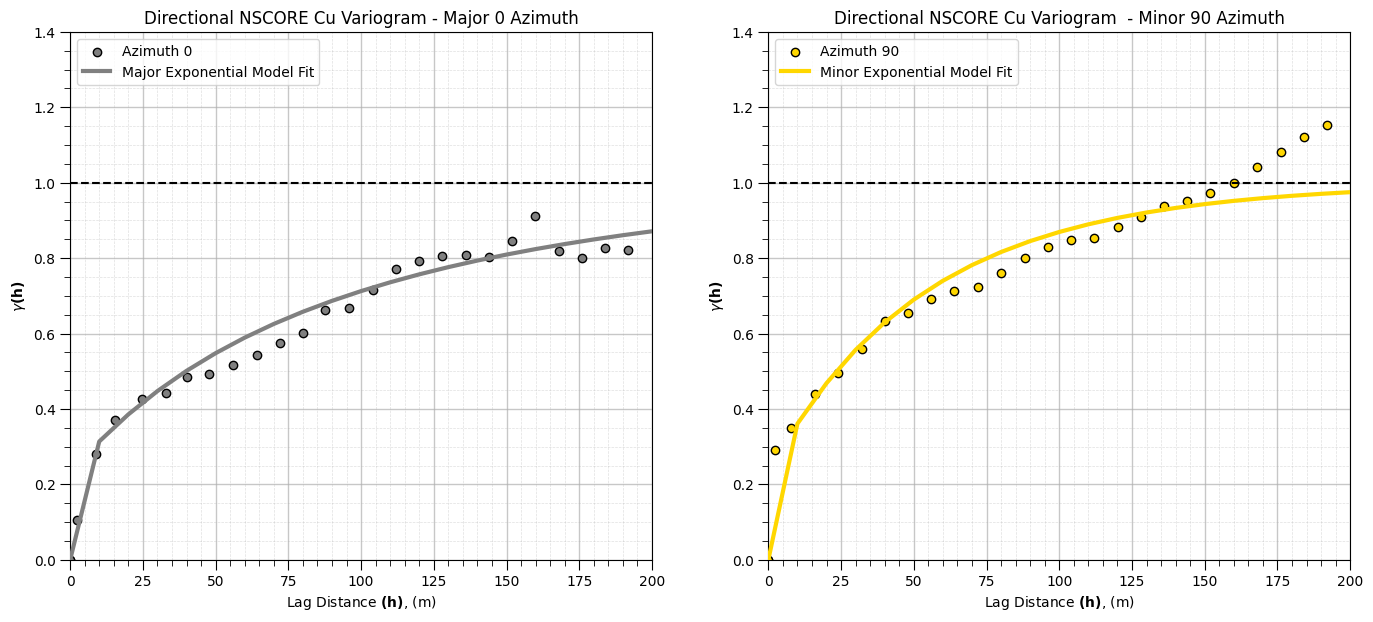

In [121]:
nug = 0.23; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 2; cc1 = 0.20; azi1 = azi_mat[imajor]; hmaj1 = 125; hmin1 = 110
it2 = 2; cc2 = (1-(nug + cc1)); azi2 = azi_mat[imajor]; hmaj2 = 400; hmin2 = 190

vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2) # make model object
nlag = 25; xlag = 10;                                          # project the model in the 045 azimuth
index_maj,h_maj,gam_maj,cov_maj,ro_maj = geostats.vmodel(nlag,xlag,azi_mat[imajor],vario)                                                     # project the model in the 135 azimuth
index_min,h_min,gam_min,cov_min,ro_min = geostats.vmodel(nlag,xlag,azi_mat[iminor],vario)

plt.subplot(1,2,1)
plt.scatter(lag[imajor,:],gamma[imajor,:],color = 'grey',edgecolor = 'black',marker = 'o',label = 'Azimuth ' +str(azi_mat[imajor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--'  )
plt.plot(h_maj,gam_maj,color = 'grey',lw = 3,zorder = 60, label = 'Major Exponential Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()

plt.subplot(1,2,2)
plt.scatter(lag[iminor,:],gamma[iminor,:],color = 'gold',edgecolor = 'black', marker = 'o',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--' ) # sill line
plt.plot(h_min,gam_min,color = 'gold',linewidth = 3,zorder = 60, label = 'Minor Exponential Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.1, wspace = 0.2, hspace = 0.3); plt.show()

#### Gaussian Fit

 x,y,z offsets = 0.0,10.0
 x,y,z offsets = 10.0,1.794896514920806e-08


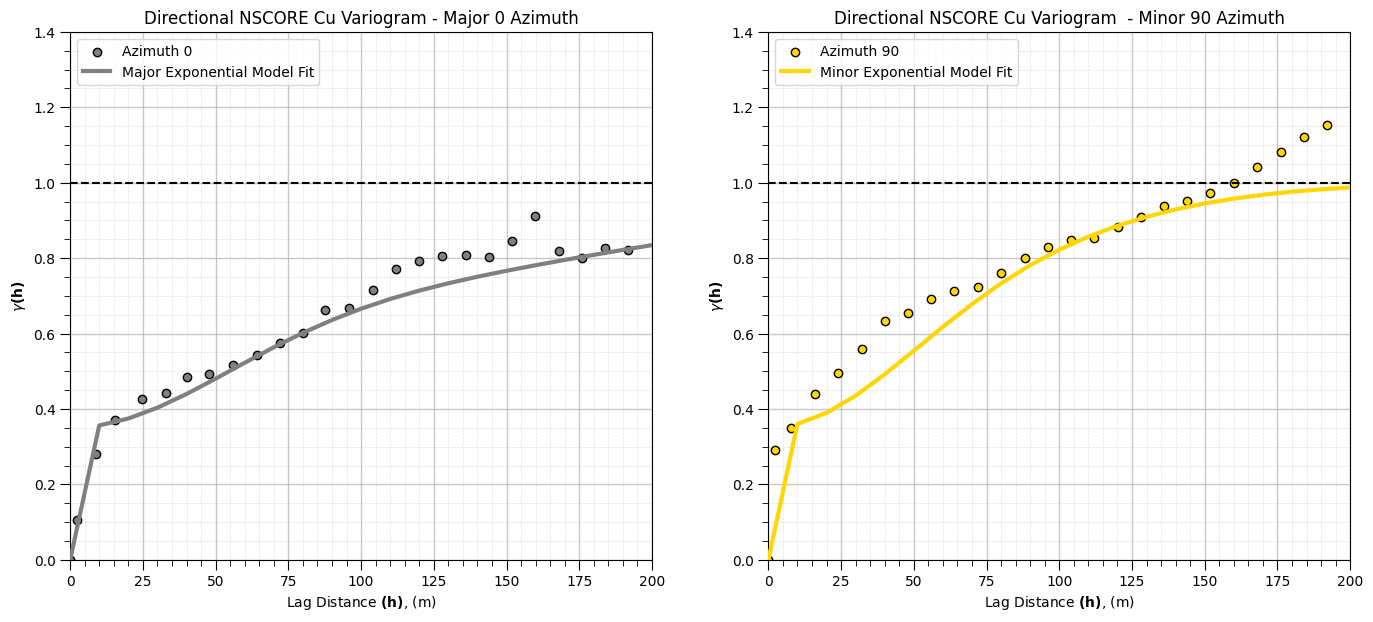

In [127]:
nug = 0.35; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 3; cc1 = 0.30; azi1 = azi_mat[imajor]; hmaj1 = 125; hmin1 = 110
it2 = 3; cc2 = (1-(nug + cc1)); azi2 = azi_mat[imajor]; hmaj2 = 400; hmin2 = 190

vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2) # make model object
nlag = 25; xlag = 10;                                          # project the model in the 045 azimuth
index_maj,h_maj,gam_maj,cov_maj,ro_maj = geostats.vmodel(nlag,xlag,azi_mat[imajor],vario)                                                     # project the model in the 135 azimuth
index_min,h_min,gam_min,cov_min,ro_min = geostats.vmodel(nlag,xlag,azi_mat[iminor],vario)

plt.subplot(1,2,1)
plt.scatter(lag[imajor,:],gamma[imajor,:],color = 'grey',edgecolor = 'black',marker = 'o',label = 'Azimuth ' +str(azi_mat[imajor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--'  )
plt.plot(h_maj,gam_maj,color = 'grey',lw = 3,zorder = 60, label = 'Major Exponential Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()

plt.subplot(1,2,2)
plt.scatter(lag[iminor,:],gamma[iminor,:],color = 'gold',edgecolor = 'black', marker = 'o',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,xlimax],[1.0,1.0],color = 'black',linestyle = '--' ) # sill line
plt.plot(h_min,gam_min,color = 'gold',linewidth = 3,zorder = 60, label = 'Minor Exponential Model Fit')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,xlimax])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.1, wspace = 0.2, hspace = 0.3); plt.show()

# **2. Interpolation Grid & Search Strategy**

# **3. IDW Interpolation (p = 1, 2, 3, 4, 5)**

### 3.1 Method

### 3.2 Maps

### 3.3 Observation summary

# **4. Simple Kriging (SK)**

### 4.1 Assumptions & setup

### 4.2 Estimation

### 4.3 Maps

# **5. Ordinary Kriging (OK)**

### 5.1 Assumptions & setup

### 5.2 Estimation

### 5.3 Maps

# **6. For each method, compute Validation & Comparative Analysis**

# **7. Observations and Conclusion**